# Home Loan Data Analysis using Deep Learning
### Loan Default Prediction Project (Curriculum Submission)

**Objective:** Build a deep learning model to predict whether a borrower will **not fully pay** a loan, using historical loan data.

**Target Column:** `not.fully.paid`  
- `0` → Fully paid (Non-default)  
- `1` → Not fully paid (Default)

This notebook follows the required project steps:
1. Load dataset  
2. Check null values  
3. Print default vs non-default percentage  
4. Handle class imbalance (balancing)  
5. Plot imbalanced vs balanced data  
6. Encode categorical columns  
7. Calculate **Sensitivity**  
8. Calculate **AUC-ROC**  

## Step 0 — Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML + DL
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

from imblearn.over_sampling import RandomOverSampler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## Step 1 — Load dataset

In [2]:
df = pd.read_csv("loan_data.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## Step 2 — Check null values

In [3]:
df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

## Step 3 — Default vs Non-default Distribution (Target Column)

We inspect whether the dataset is imbalanced.  
If the dataset is imbalanced, accuracy alone can be misleading, so we will also evaluate:
- **Sensitivity (Recall for defaulters)**
- **ROC-AUC**


In [4]:
target_counts = df["not.fully.paid"].value_counts()
target_percent = df["not.fully.paid"].value_counts(normalize=True) * 100

print("Target counts:\n", target_counts)
print("\nTarget percentages (%):\n", target_percent.round(2))

Target counts:
 not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

Target percentages (%):
 not.fully.paid
0    83.99
1    16.01
Name: proportion, dtype: float64


### Plot target distribution (Imbalanced dataset)

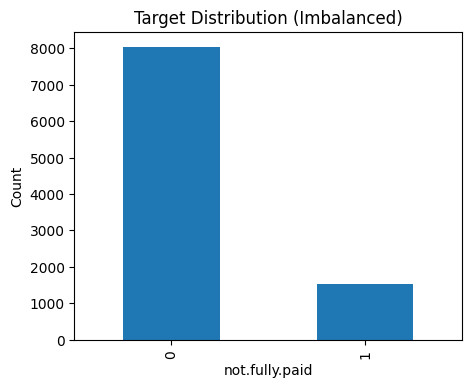

In [5]:
plt.figure(figsize=(5,4))
df["not.fully.paid"].value_counts().plot(kind="bar")
plt.title("Target Distribution (Imbalanced)")
plt.xlabel("not.fully.paid")
plt.ylabel("Count")
plt.show()

## Step 4 — Train/Test Split (Stratified)

We split data into training and testing while preserving class distribution using `stratify=y`.


In [6]:
X = df.drop("not.fully.paid", axis=1)
y = df["not.fully.paid"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts())
print("\nTest target distribution:\n", y_test.value_counts())

Train shape: (7662, 13) Test shape: (1916, 13)

Train target distribution:
 not.fully.paid
0    6436
1    1226
Name: count, dtype: int64

Test target distribution:
 not.fully.paid
0    1609
1     307
Name: count, dtype: int64


## Step 4 (continued) — Balance the dataset (Oversampling)

Since the dataset is imbalanced, we use **Random Oversampling** on the **training data only**.
This ensures the model learns both classes properly without leaking test data information.


In [7]:
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

print("Before balancing:\n", y_train.value_counts())
print("\nAfter balancing:\n", y_train_bal.value_counts())

Before balancing:
 not.fully.paid
0    6436
1    1226
Name: count, dtype: int64

After balancing:
 not.fully.paid
0    6436
1    6436
Name: count, dtype: int64


## Step 5 — Plot imbalanced vs balanced training data

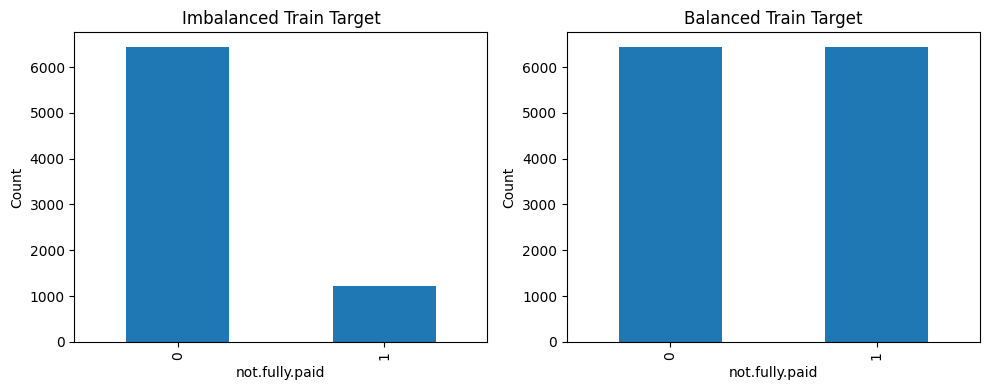

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

y_train.value_counts().plot(kind="bar", ax=ax[0], title="Imbalanced Train Target")
y_train_bal.value_counts().plot(kind="bar", ax=ax[1], title="Balanced Train Target")

for a in ax:
    a.set_xlabel("not.fully.paid")
    a.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Step 6 — Encode required columns + Scaling

The dataset contains one categorical column:
- `purpose`

We apply:
- **OneHotEncoding** for categorical features  
- **StandardScaler** for numeric features


In [9]:
cat_cols = ["purpose"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train_bal)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (12872, 19)
Processed test shape: (1916, 19)


## Deep Learning Model

We build a neural network for binary classification:

- Dense layers with ReLU activation
- Dropout layers for regularization
- Sigmoid output layer for probability prediction


In [10]:
input_dim = X_train_processed.shape[1]

model = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()

C:\Users\viswa\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,881 (42.50 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [11]:
# Some transformers output sparse matrices; convert safely if needed
X_train_input = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_input = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

history = model.fit(
    X_train_input, y_train_bal,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6581 - auc: 0.6647 - loss: 0.6225 - val_accuracy: 0.4140 - val_auc: 0.0000e+00 - val_loss: 0.8318
Epoch 2/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6751 - auc: 0.6878 - loss: 0.6089 - val_accuracy: 0.3829 - val_auc: 0.0000e+00 - val_loss: 0.8906
Epoch 3/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6831 - auc: 0.6986 - loss: 0.6013 - val_accuracy: 0.3883 - val_auc: 0.0000e+00 - val_loss: 0.8420
Epoch 4/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6805 - auc: 0.7078 - loss: 0.5963 - val_accuracy: 0.4392 - val_auc: 0.0000e+00 - val_loss: 0.8109
Epoch 5/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6919 - auc: 0.7144 - loss: 0.5922 - val_accuracy: 0.3775 - val_auc: 0.0000e+00 - val_loss: 0.8672
Epoch 6/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6921 - auc: 0.7169 - loss: 0.5902 - val_accuracy: 0.3480 - val_auc: 0.0000e+00 - val_loss: 0.9188
Epoch 7/25
322/3

### Training Curves

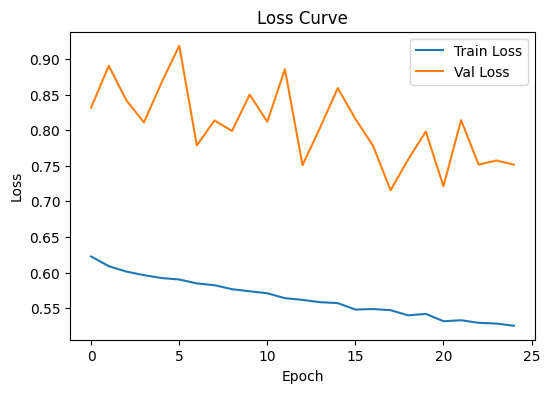

In [12]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Evaluate Model (Predictions)

We predict probabilities and then convert them to class labels using threshold = 0.5.

In [13]:
y_pred_proba = model.predict(X_test_input).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
cm

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([[1391,  218],
       [ 220,   87]])

## Step 7 — Calculate Sensitivity

**Sensitivity = TP / (TP + FN)**  
This measures how well the model detects loan defaulters (the positive class).

In [14]:
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)
print("Sensitivity:", round(sensitivity, 4))

TN: 1391 FP: 218 FN: 220 TP: 87
Sensitivity: 0.2834


## Step 8 — ROC Curve and AUC Score

- ROC shows trade-off between TPR and FPR  
- AUC provides a single performance score across thresholds

AUC ROC Score: 0.655


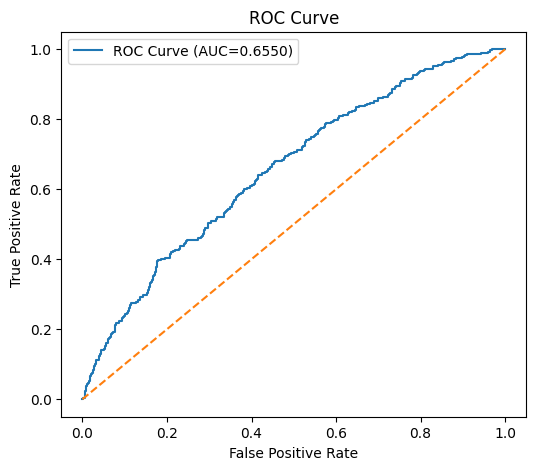

In [15]:
auc_score = roc_auc_score(y_test, y_pred_proba)
print("AUC ROC Score:", round(auc_score, 4))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC={auc_score:.4f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## (Optional Enhancement) Threshold Tuning

In finance default detection, it is better to **catch defaulters**, even if false positives increase.  
We show how sensitivity improves when reducing classification threshold.

In [16]:
threshold = 0.35
y_pred_tuned = (y_pred_proba >= threshold).astype(int)
cm2 = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm2.ravel()

sensitivity2 = tp / (tp + fn)

print("Threshold:", threshold)
print("Confusion Matrix:\n", cm2)
print("Sensitivity:", round(sensitivity2, 4))

Threshold: 0.35
Confusion Matrix:
 [[1040  569]
 [ 138  169]]
Sensitivity: 0.5505


## Conclusion

We successfully:
- Loaded and explored the dataset
- Checked missing values
- Verified and handled class imbalance
- Encoded categorical features and scaled numerics
- Built and trained a deep learning classifier
- Evaluated using **Sensitivity** and **ROC-AUC**